In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [41]:
import pandas as pd  # 파일입력(read_excel), 교차표(crosstab), 원핫인코딩(get_dummies)
import numpy as np
from sklearn.model_selection import train_test_split #훈련셋과 시험셋 분리함수
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model

# dropout은 과적합을 줄이기 위한 방법 : dropout
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization 
from tensorflow.keras.regularizers import l2
#데이터 불균형 극복 5.5 : 4.5 => 5:5
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt #시각화
from sklearn.metrics import confusion_matrix #혼동행렬

# 이진분류(로지스틱 회귀분석)
- 1. 데이터셋 생성 & 전처리
    * 엑셀 -> 데이터프레임 -> ?처리 ..(결측치로 전환하여 결측치처리) -> X, y 분리
       -> X변수의 scale조정 -> train_test_split()을 이용하여 학습셋과 테스트셋을 분리
- 2. 모델 생성(입력13, 타겟1) - 과적합을 고려 & 학습과정 설정 & 학습
- 3. 모델 평가(그래프, 평가, 혼동행렬=교차표)
- 4. 모델 사용

## 1. 데이터셋 생성 & 전처리

In [44]:
df=pd.read_excel('data/heart-disease.xlsx',sheet_name='processed.cleveland')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [5]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [6]:
# 결측치 없는것 확인 but type중 object가 있음

In [7]:
df.isin(['?']).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [45]:
df[(df['chol']=='?')|(df['ca']=='?')|(df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [47]:
#방법1 : ? 가 있는 행을 삭제
drop_idx=df[(df['chol']=='?')|(df['ca']=='?')|(df['hsl']=='?')].index
df=df.drop(drop_idx)

In [48]:
#방법2 ?를 결측치로 대체 => 결측치 삭제
df=df.replace('?',np.nan)
df[(df['chol']=='?')|(df['ca']=='?')|(df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [10]:
df[(df['chol'].isna())|(df['ca'].isna())|(df['hsl'].isna())]
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
87,53,0,3,128,216.0,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223.0,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247.0,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204.0,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220.0,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175.0,0,0,173,0,0.0,1,NaN,3.0,0


In [11]:
# 결측치 처리 : 삭제(dropna) cf.fillna() apply()
df=df.dropna(how='any') #결측치가 한 열이라도 있으면 삭제

In [49]:
df.shape

(296, 14)

In [13]:
#타겟변수 확인
df['heartDisease'].value_counts()/df.shape[0]

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [14]:
df['heartDisease'].value_counts(normalize=True)

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [15]:
# X,y분리 
X=df.iloc[:,:-1].values
y=df.iloc[:,-1:].values
X.shape, y.shape

((296, 13), (296, 1))

In [50]:
# X변수의 scale 조정
scaler= MinMaxScaler()
scaled_X=scaler.fit_transform(X)
print('원데이터:',X[0])
print('스케일 조정 데이터 :\n', scaled_X[0])

원데이터: [ 63.    1.    1.  145.  233.    1.    2.  150.    0.    2.3   3.    0.
   6. ]
스케일 조정 데이터 :
 [0.70833333 1.         0.         0.48113208 0.24429224 1.
 1.         0.60305344 0.         0.37096774 1.         0.
 0.75      ]


In [17]:
# scaled_X와 y를 학습데이터셋: 테스트셋 = 8:2
X_train, X_test, y_train, y_test=train_test_split(scaled_X, 
                                 y,
                                 #train_size=0.8
                                 test_size=0.2,
                                 random_state=7,
                                 stratify=y #층화추출

In [18]:
#심장병 음성/양성 비율(y, y_train, y_test)   = > y의 train과 test 비율이 다름
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.542373
1    0.457627
dtype: float64
0    0.533333
1    0.466667
dtype: float64


## 2. 모델생성 & 학습과정 설정 & 학습
- 모델 : 13 -> 32 -> 16 -> 8 -> 1

- 학습과정을 시각화한 그래프를 보고 과적합 줄이기
- 과정합 줄이기 위한방법
    * dropout : 학습할 때마다 일부 뉴런을 랜덤하게 끄기, 특정 뉴런 조합에 과하게 의존하는 것을 막아줌
    * BatchNormalization(배치 정규화) : 각 층의 출력을 정규화해서 더 안정적이고 빠르게 수렵하도록 도와줌
    * L2 정규화(규제) : 가중치가 너무 커지지 않게 학습과정에서 미리 누름. 가중치가 크면 입력값이 살짝 바뀌어도 출력이 확 바뀜. 규제를 세게(0.01) / 규제중간(0.001) / 규제약하게(0.0001)
    

In [53]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((236, 13), (236, 1), (60, 13), (60, 1))

In [135]:


model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units= 32, activation='relu',
               kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units= 16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units= 8, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units= 1, activation='sigmoid')) 
model.summary() 
#Dense층 뒤에 배치정규화층에서 파라미터 : Dense층 출력갯수 *4
    #ggamma (스케일) - 32(학습됨)
    #beta(이동)      - 32(학습됨)
    #moving_mean(이동평균) -32(학습안됨)
    #moving_variance(이동분산)  -32(학습안됨)

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_48 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_15 (Bat  (None, 32)               128       
 chNormalization)                                                
                                                                 
 dropout_15 (Dropout)        (None, 32)                0         
                                                                 
 dense_49 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_16 (Bat  (None, 16)               64        
 chNormalization)                                                
                                                                 
 dropout_16 (Dropout)        (None, 16)              

In [136]:
# recall 과 precision 을  출력하고 싶으면 import 필요
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              #optimizer='adam', #0.001을 자동으로 지정
              metrics=['accuracy',
                       Recall(name='recall'),   # 재현율(실제값 중심=1을 얼마나 잘 예측했는지)/  
                       Precision(name='precision')])  #정밀도(예측값 중심 =1이라고 예측한 것중 얼마나 1인지)

(array([0, 1], dtype=int64), array([128, 108], dtype=int64))

In [150]:
# 클래스(0/1) 가중치 계산 (55:45 정도의 비율 => 50:50)
from sklearn.utils.class_weight import compute_class_weight
y_train_flat = y_train.flatten() #y_train.reshape(-1)
class_weight = compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_train_flat),
                y = y_train_flat )
print('class_weight :', class_weight)
class_weight_dict = dict(enumerate(class_weight))
print('학습시 가중치 조정값 :', class_weight_dict)
# y_train의 빈도수(0은?개, 1은?개)
values, counts = np.unique(y_train_flat, return_counts=True)
print('빈도수 :', dict(zip(values, counts)))
print(counts[0]*class_weight_dict[0], counts[1]*class_weight_dict[1])
# 빈도 분포
ratios = counts / counts.sum()
print(ratios[0]*class_weight_dict[0], ratios[1]*class_weight_dict[1])

class_weight : [0.921875   1.09259259]
학습시 가중치 조정값 : {0: 0.921875, 1: 1.0925925925925926}
빈도수 : {0: 128, 1: 108}
118.0 118.0
0.5 0.5


In [138]:
# callback 설정 : 학습을 할 때 마다 
# ReduceLROnPlateau : 성능이 정체되면 (validation loss가 늘어나면) 학습률(learning rate)을 낮춰서 세밀하게 탐색
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5, #학습률을 원학습률의 절반으로
                              patience=7, #7번 연속 개선이 없으면
                              min_lr=1e-6 # 학습률의 최소값 10의 -6승이하로는 안내려가게
                              )

In [139]:
#학습
hist=model.fit(X_train,y_train,
               epochs=200,
               validation_split=0.2, #학습데이터에서 20%를 검증데이터로 사용
               class_weight=class_weight_dict, # loss 계산시 얼마나 더 중요하게 취급될지의 가중치
               callbacks=[reduce_lr],
               verbose=2) 

Epoch 1/200
6/6 - 3s - loss: 0.9413 - accuracy: 0.4894 - recall: 0.3678 - precision: 0.4384 - val_loss: 0.7153 - val_accuracy: 0.4583 - val_recall: 0.9524 - val_precision: 0.4444 - lr: 0.0010 - 3s/epoch - 516ms/step
Epoch 2/200
6/6 - 0s - loss: 0.9047 - accuracy: 0.5426 - recall: 0.4483 - precision: 0.5065 - val_loss: 0.7089 - val_accuracy: 0.5417 - val_recall: 0.7143 - val_precision: 0.4839 - lr: 0.0010 - 55ms/epoch - 9ms/step
Epoch 3/200
6/6 - 0s - loss: 0.8039 - accuracy: 0.5904 - recall: 0.5057 - precision: 0.5641 - val_loss: 0.7032 - val_accuracy: 0.5833 - val_recall: 0.5714 - val_precision: 0.5217 - lr: 0.0010 - 54ms/epoch - 9ms/step
Epoch 4/200
6/6 - 0s - loss: 0.7677 - accuracy: 0.5798 - recall: 0.5057 - precision: 0.5500 - val_loss: 0.6972 - val_accuracy: 0.6250 - val_recall: 0.5714 - val_precision: 0.5714 - lr: 0.0010 - 52ms/epoch - 9ms/step
Epoch 5/200
6/6 - 0s - loss: 0.7783 - accuracy: 0.6064 - recall: 0.5172 - precision: 0.5844 - val_loss: 0.6910 - val_accuracy: 0.6667 - 

Epoch 39/200
6/6 - 0s - loss: 0.4996 - accuracy: 0.7606 - recall: 0.7011 - precision: 0.7625 - val_loss: 0.5029 - val_accuracy: 0.7708 - val_recall: 0.6667 - val_precision: 0.7778 - lr: 0.0010 - 47ms/epoch - 8ms/step
Epoch 40/200
6/6 - 0s - loss: 0.5007 - accuracy: 0.7872 - recall: 0.7011 - precision: 0.8133 - val_loss: 0.4989 - val_accuracy: 0.7708 - val_recall: 0.6667 - val_precision: 0.7778 - lr: 0.0010 - 49ms/epoch - 8ms/step
Epoch 41/200
6/6 - 0s - loss: 0.4701 - accuracy: 0.8298 - recall: 0.7126 - precision: 0.8986 - val_loss: 0.4962 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - lr: 0.0010 - 49ms/epoch - 8ms/step
Epoch 42/200
6/6 - 0s - loss: 0.4905 - accuracy: 0.7606 - recall: 0.6782 - precision: 0.7763 - val_loss: 0.4930 - val_accuracy: 0.8125 - val_recall: 0.7619 - val_precision: 0.8000 - lr: 0.0010 - 61ms/epoch - 10ms/step
Epoch 43/200
6/6 - 0s - loss: 0.5142 - accuracy: 0.7660 - recall: 0.7011 - precision: 0.7722 - val_loss: 0.4905 - val_accuracy: 0.8

Epoch 77/200
6/6 - 0s - loss: 0.4772 - accuracy: 0.7872 - recall: 0.7356 - precision: 0.7901 - val_loss: 0.4510 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 62ms/epoch - 10ms/step
Epoch 78/200
6/6 - 0s - loss: 0.4523 - accuracy: 0.8351 - recall: 0.7816 - precision: 0.8500 - val_loss: 0.4516 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 51ms/epoch - 8ms/step
Epoch 79/200
6/6 - 0s - loss: 0.4778 - accuracy: 0.8032 - recall: 0.7241 - precision: 0.8289 - val_loss: 0.4520 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 57ms/epoch - 9ms/step
Epoch 80/200
6/6 - 0s - loss: 0.4592 - accuracy: 0.8298 - recall: 0.7701 - precision: 0.8481 - val_loss: 0.4548 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 48ms/epoch - 8ms/step
Epoch 81/200
6/6 - 0s - loss: 0.4147 - accuracy: 0.8351 - recall: 0.7816 - precision: 0.8500 - val_loss: 0.4555 - val_accuracy: 0.8

Epoch 115/200
6/6 - 0s - loss: 0.4006 - accuracy: 0.8511 - recall: 0.8046 - precision: 0.8642 - val_loss: 0.4401 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 5.0000e-04 - 59ms/epoch - 10ms/step
Epoch 116/200
6/6 - 0s - loss: 0.4000 - accuracy: 0.8298 - recall: 0.7701 - precision: 0.8481 - val_loss: 0.4404 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 5.0000e-04 - 45ms/epoch - 8ms/step
Epoch 117/200
6/6 - 0s - loss: 0.4362 - accuracy: 0.8138 - recall: 0.7586 - precision: 0.8250 - val_loss: 0.4406 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 5.0000e-04 - 45ms/epoch - 8ms/step
Epoch 118/200
6/6 - 0s - loss: 0.3900 - accuracy: 0.8404 - recall: 0.7816 - precision: 0.8608 - val_loss: 0.4411 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 5.0000e-04 - 75ms/epoch - 13ms/step
Epoch 119/200
6/6 - 0s - loss: 0.3880 - accuracy: 0.8511 - recall: 0.8046 - precision: 0.8642 - val_loss: 0.44

Epoch 152/200
6/6 - 0s - loss: 0.4230 - accuracy: 0.8351 - recall: 0.8161 - precision: 0.8256 - val_loss: 0.4426 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 1.5625e-05 - 52ms/epoch - 9ms/step
Epoch 153/200
6/6 - 0s - loss: 0.4138 - accuracy: 0.8404 - recall: 0.7816 - precision: 0.8608 - val_loss: 0.4425 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 1.5625e-05 - 44ms/epoch - 7ms/step
Epoch 154/200
6/6 - 0s - loss: 0.3998 - accuracy: 0.8457 - recall: 0.8046 - precision: 0.8537 - val_loss: 0.4423 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 7.8125e-06 - 41ms/epoch - 7ms/step
Epoch 155/200
6/6 - 0s - loss: 0.4914 - accuracy: 0.7819 - recall: 0.7241 - precision: 0.7875 - val_loss: 0.4426 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 7.8125e-06 - 50ms/epoch - 8ms/step
Epoch 156/200
6/6 - 0s - loss: 0.4036 - accuracy: 0.8298 - recall: 0.7931 - precision: 0.8313 - val_loss: 0.4426

Epoch 189/200
6/6 - 0s - loss: 0.4560 - accuracy: 0.8191 - recall: 0.7701 - precision: 0.8272 - val_loss: 0.4432 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 1.0000e-06 - 62ms/epoch - 10ms/step
Epoch 190/200
6/6 - 0s - loss: 0.4411 - accuracy: 0.8191 - recall: 0.7586 - precision: 0.8354 - val_loss: 0.4430 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 1.0000e-06 - 51ms/epoch - 9ms/step
Epoch 191/200
6/6 - 0s - loss: 0.4322 - accuracy: 0.8511 - recall: 0.8161 - precision: 0.8554 - val_loss: 0.4431 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 1.0000e-06 - 62ms/epoch - 10ms/step
Epoch 192/200
6/6 - 0s - loss: 0.3937 - accuracy: 0.8351 - recall: 0.7816 - precision: 0.8500 - val_loss: 0.4432 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 1.0000e-06 - 65ms/epoch - 11ms/step
Epoch 193/200
6/6 - 0s - loss: 0.3658 - accuracy: 0.8830 - recall: 0.8276 - precision: 0.9114 - val_loss: 0.4

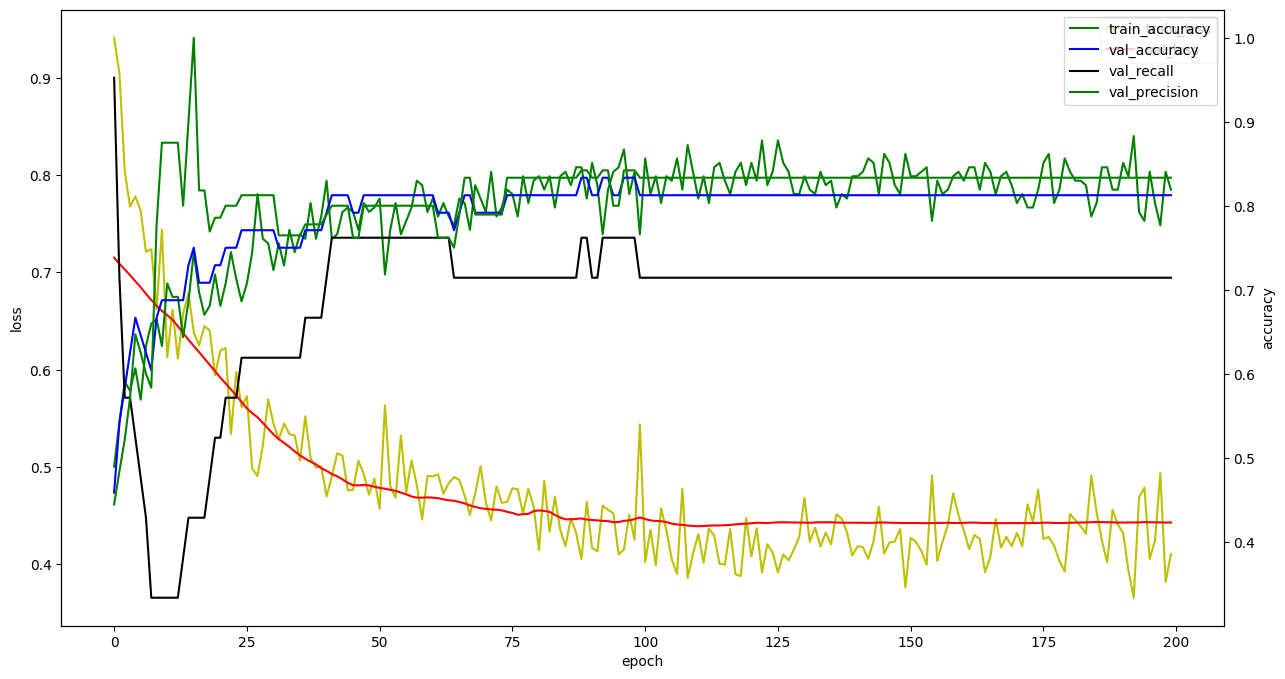

In [145]:
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')
acc_ax.plot(hist.history['val_precision'],'g',label='val_precision')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()

## 3. 모델 평가(그래프, 평가, 교차표)

In [73]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision'])

In [147]:
# 평가
score =model.evaluate(X_test,y_test)
print(f'model loss : {score[0]}')
print(f'model accuracy : {score[1]*100:.2f}%')
print(f'model recall : {score[2]*100:.2f}%')
print(f'model precision : {score[3]*100:.2f}%')

2/2 [==============================] - 0s 3ms/step - loss: 0.3696 - accuracy: 0.8833 - recall: 0.8571 - precision: 0.8889
model loss : 0.3695993721485138
model accuracy : 88.33%
model recall : 85.71%
model precision : 88.89%


In [152]:
y_test.reshape(-1)

array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [155]:
# 교차표(혼동행렬)
#교차표에서의 실제값 : y_test.reshape(-1)
y_hat=(model.predict(X_test) >0.5).astype(int).reshape(-1) #예측값을 1차원으로
                                        # 01과 1의 기준값 0.5를 이동하면 recall과 precision이 바뀜

2/2 [==============================] - 0s 6ms/step


In [156]:
pd.crosstab(y_test.reshape(-1),
            y_hat,
            rownames=['실제값'],
            colnames=['예측값'])

예측값,0,1
실제값,,
0,29,3
1,4,24


In [157]:
confusion_matrix(y_test,y_hat)

array([[29,  3],
       [ 4, 24]], dtype=int64)

## 4. 모델 사용
 - 저장/예측

In [ ]:
model.save('model/06.h5')
save_model(model,'model/06.h5')
model1=load_model('model/06.h5')


In [165]:
data= [X[0].astype(int)]

In [166]:
data

[array([ 63,   1,   1, 145, 233,   1,   2, 150,   0,   2,   3,   0,   6])]

In [167]:
input_data=scaler.transform(data)
(model.predict(input_data)>0.5).astype(int)

1/1 [==============================] - 0s 22ms/step


array([[0]])

In [168]:
y[0]

array([0], dtype=int64)

# 분류분석으로 
- 1. 데이터셋생성 & 전처리
    * X_train, y_train, X_test, y_test -> y_train과 y_test 를 원핫인코딩
- 2. 모델생성 & 학습과정 설정 & 모델 학습
- 3. 모델평가(학습과정 시각화, 평가, 교차표 argmax이용)
- 4. 모델 사용 (저장, 예측)


## 1. 데이터셋 생성 & 전처리
```
- y_train, y_test 원핫인코딩
    0 -> 1 0 
    1 -> 0 1
```

In [175]:
Y_train=to_categorical(y_train)
Y_test=to_categorical(y_test,2)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((236, 13), (236, 2), (60, 13), (60, 2))

## 2. 모델생성 &학습과정 설정 & 학습

In [176]:
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units= 32, activation='relu',
               kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units= 16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units= 8, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units= 2, activation='softmax'))  # 분류분석 출력층의 활성화함수
model.summary() 

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_52 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_18 (Bat  (None, 32)               128       
 chNormalization)                                                
                                                                 
 dropout_18 (Dropout)        (None, 32)                0         
                                                                 
 dense_53 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_19 (Bat  (None, 16)               64        
 chNormalization)                                                
                                                                 
 dropout_19 (Dropout)        (None, 16)              

In [177]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy',
                    Recall(name='recall'), Precision(name='precision')])

In [180]:
%%time
hist=model.fit(X_train,Y_train,
              epochs=200,
              validation_split=0.2,
              callbacks=[reduce_lr],
              verbose=2)

Epoch 1/200
6/6 - 2s - loss: 1.0515 - accuracy: 0.4947 - recall: 0.4947 - precision: 0.4947 - val_loss: 0.6980 - val_accuracy: 0.5833 - val_recall: 0.5833 - val_precision: 0.5833 - lr: 0.0010 - 2s/epoch - 354ms/step
Epoch 2/200
6/6 - 0s - loss: 0.9250 - accuracy: 0.4947 - recall: 0.4947 - precision: 0.4947 - val_loss: 0.6942 - val_accuracy: 0.5833 - val_recall: 0.5833 - val_precision: 0.5833 - lr: 0.0010 - 44ms/epoch - 7ms/step
Epoch 3/200
6/6 - 0s - loss: 0.8453 - accuracy: 0.5691 - recall: 0.5691 - precision: 0.5691 - val_loss: 0.6912 - val_accuracy: 0.5833 - val_recall: 0.5833 - val_precision: 0.5833 - lr: 0.0010 - 50ms/epoch - 8ms/step
Epoch 4/200
6/6 - 0s - loss: 0.9316 - accuracy: 0.4894 - recall: 0.4894 - precision: 0.4894 - val_loss: 0.6831 - val_accuracy: 0.6458 - val_recall: 0.6458 - val_precision: 0.6458 - lr: 0.0010 - 64ms/epoch - 11ms/step
Epoch 5/200
6/6 - 0s - loss: 0.9656 - accuracy: 0.4681 - recall: 0.4681 - precision: 0.4681 - val_loss: 0.6720 - val_accuracy: 0.6875 -

Epoch 39/200
6/6 - 0s - loss: 0.5137 - accuracy: 0.7606 - recall: 0.7606 - precision: 0.7606 - val_loss: 0.4955 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010 - 48ms/epoch - 8ms/step
Epoch 40/200
6/6 - 0s - loss: 0.5555 - accuracy: 0.7340 - recall: 0.7340 - precision: 0.7340 - val_loss: 0.4912 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010 - 57ms/epoch - 10ms/step
Epoch 41/200
6/6 - 0s - loss: 0.5348 - accuracy: 0.7074 - recall: 0.7074 - precision: 0.7074 - val_loss: 0.4863 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010 - 41ms/epoch - 7ms/step
Epoch 42/200
6/6 - 0s - loss: 0.5025 - accuracy: 0.7872 - recall: 0.7872 - precision: 0.7872 - val_loss: 0.4816 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010 - 42ms/epoch - 7ms/step
Epoch 43/200
6/6 - 0s - loss: 0.5186 - accuracy: 0.7713 - recall: 0.7713 - precision: 0.7713 - val_loss: 0.4779 - val_accuracy: 0.7

Epoch 77/200
6/6 - 0s - loss: 0.4869 - accuracy: 0.8032 - recall: 0.8032 - precision: 0.8032 - val_loss: 0.4215 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 0.0010 - 59ms/epoch - 10ms/step
Epoch 78/200
6/6 - 0s - loss: 0.4240 - accuracy: 0.8564 - recall: 0.8564 - precision: 0.8564 - val_loss: 0.4198 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 0.0010 - 41ms/epoch - 7ms/step
Epoch 79/200
6/6 - 0s - loss: 0.4557 - accuracy: 0.7926 - recall: 0.7926 - precision: 0.7926 - val_loss: 0.4196 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 0.0010 - 61ms/epoch - 10ms/step
Epoch 80/200
6/6 - 0s - loss: 0.4578 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4195 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 0.0010 - 48ms/epoch - 8ms/step
Epoch 81/200
6/6 - 0s - loss: 0.4930 - accuracy: 0.7447 - recall: 0.7447 - precision: 0.7447 - val_loss: 0.4178 - val_accuracy: 0.

Epoch 115/200
6/6 - 0s - loss: 0.4624 - accuracy: 0.7926 - recall: 0.7926 - precision: 0.7926 - val_loss: 0.4233 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 6.2500e-05 - 52ms/epoch - 9ms/step
Epoch 116/200
6/6 - 0s - loss: 0.4217 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4234 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 6.2500e-05 - 47ms/epoch - 8ms/step
Epoch 117/200
6/6 - 0s - loss: 0.4565 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4231 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 6.2500e-05 - 55ms/epoch - 9ms/step
Epoch 118/200
6/6 - 0s - loss: 0.4648 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4234 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 3.1250e-05 - 45ms/epoch - 8ms/step
Epoch 119/200
6/6 - 0s - loss: 0.4279 - accuracy: 0.8404 - recall: 0.8404 - precision: 0.8404 - val_loss: 0.4236

Epoch 152/200
6/6 - 0s - loss: 0.4411 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4253 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.9531e-06 - 47ms/epoch - 8ms/step
Epoch 153/200
6/6 - 0s - loss: 0.4448 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4252 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.0000e-06 - 48ms/epoch - 8ms/step
Epoch 154/200
6/6 - 0s - loss: 0.4180 - accuracy: 0.8404 - recall: 0.8404 - precision: 0.8404 - val_loss: 0.4253 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.0000e-06 - 59ms/epoch - 10ms/step
Epoch 155/200
6/6 - 0s - loss: 0.4200 - accuracy: 0.8298 - recall: 0.8298 - precision: 0.8298 - val_loss: 0.4252 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.0000e-06 - 47ms/epoch - 8ms/step
Epoch 156/200
6/6 - 0s - loss: 0.4288 - accuracy: 0.8351 - recall: 0.8351 - precision: 0.8351 - val_loss: 0.425

Epoch 189/200
6/6 - 0s - loss: 0.4279 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4257 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.0000e-06 - 44ms/epoch - 7ms/step
Epoch 190/200
6/6 - 0s - loss: 0.4733 - accuracy: 0.8032 - recall: 0.8032 - precision: 0.8032 - val_loss: 0.4256 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.0000e-06 - 51ms/epoch - 9ms/step
Epoch 191/200
6/6 - 0s - loss: 0.4609 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.4256 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.0000e-06 - 58ms/epoch - 10ms/step
Epoch 192/200
6/6 - 0s - loss: 0.5053 - accuracy: 0.8032 - recall: 0.8032 - precision: 0.8032 - val_loss: 0.4257 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 1.0000e-06 - 59ms/epoch - 10ms/step
Epoch 193/200
6/6 - 0s - loss: 0.4199 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.42

## 3. 모델 평가(시각화, 평가,교차표)

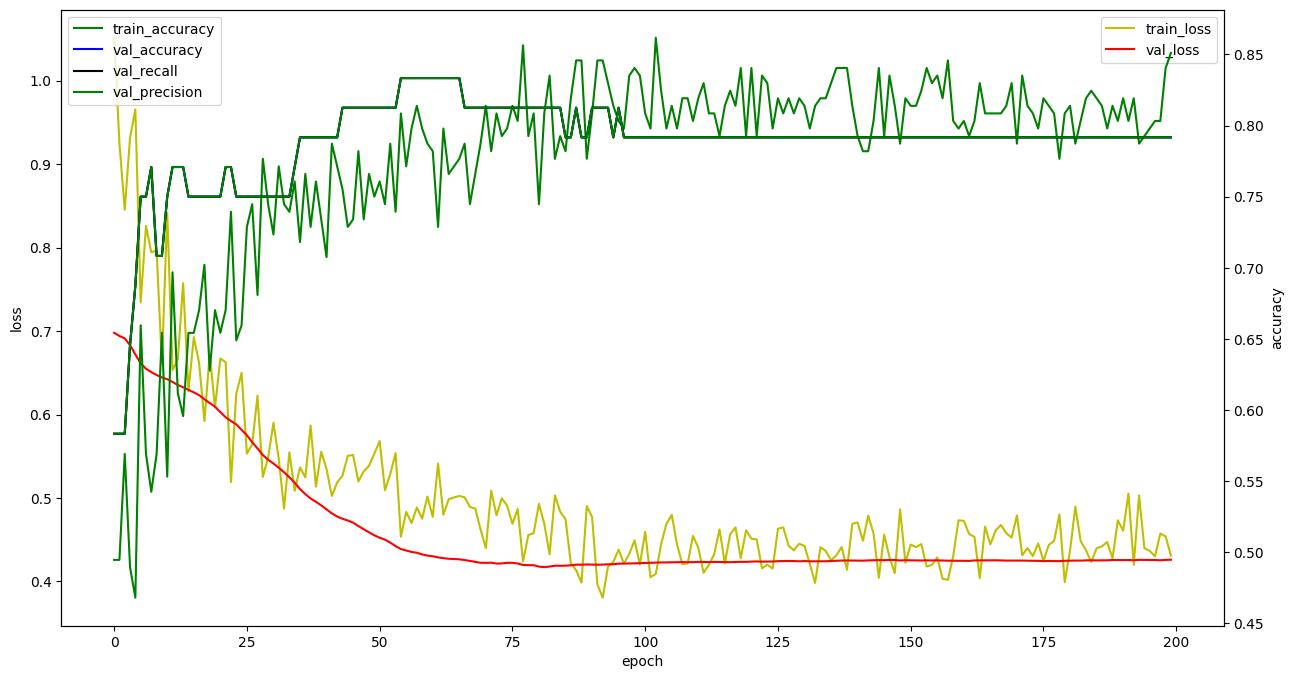

In [185]:
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')
acc_ax.plot(hist.history['val_precision'],'g',label='val_precision')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()

In [188]:
# 평가
loss, accuracy, precision, recall =model.evaluate(X_test,Y_test, verbose=0)
print(f'model loss :', loss)
print(f'model accuracy : {accuracy*100:.2f}%')
print(f'model recall : {precision*100:.2f}%')
print(f'model precision : {recall*100:.2f}%')

model loss : 0.37145230174064636
model accuracy : 86.67%
model recall : 86.67%
model precision : 86.67%


In [191]:
#교차표
y_test.reshape(-1)

array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [195]:
y_hat=model.predict(X_test,verbose=0).argmax(axis=1)
y_test.shape, y_hat.shape

((60, 1), (60,))

In [196]:
pd.crosstab(y_test.reshape(-1),y_hat, rownames=['실제값'],colnames=['예측값'])

예측값,0,1
실제값,,
0,28,4
1,4,24


In [197]:
confusion_matrix(y_test,y_hat)

array([[28,  4],
       [ 4, 24]], dtype=int64)

## 모델 사용
- 저장 / 예측

In [ ]:
model.save('model/06.h5')
save_model(model,'model/06.h5')

In [214]:
data=X[:2]
y[:2] 

array([[0],
       [1]], dtype=int64)

In [210]:
input_data = scaler.transform(data)
model.predict(input_data).argmax(axis=1)

1/1 [==============================] - 0s 24ms/step


array([0, 1], dtype=int64)